# Домашнее задание 7. XAI

Работаем с World Happiness Report 2021 и сравниваем несколько способов интерпретации: коэффициенты моделей, ICE/PDP/ALE, permutation/occlusion importance, SHAP и LIME.


In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".matplotlib_cache").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


Matplotlib is building the font cache; this may take a moment.


## Подготовка данных

Целевая переменная — `Ladder score`. Остальные столбцы используем как признаки. `Dystopia + residual` — техническое слагаемое разложения WHR: базовый уровень плюс необъяснённый остаток.


In [2]:
data_path = Path("world-happiness-report-2021-prep.csv")
data_to_work = pd.read_csv(data_path)

X = data_to_work.drop("Ladder score", axis=1)
y = data_to_work["Ladder score"]
feature_names = X.columns.to_list()

feature_idx = feature_names.index("Logged GDP per capita")
feature_name = feature_names[feature_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

sc_minmax = MinMaxScaler()
X_train_minmax = sc_minmax.fit_transform(X_train)
X_test_minmax = sc_minmax.transform(X_test)

sc_standard = StandardScaler()
X_train_standard = sc_standard.fit_transform(X_train)
X_test_standard = sc_standard.transform(X_test)

print(data_to_work.shape)
print(f"Feature for plots: {feature_name}")
data_to_work.head()


(149, 8)
Feature for plots: Logged GDP per capita


,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


## Задание 1. Шесть моделей

Сравним LinearRegression, Lasso и GradientBoostingRegressor на двух вариантах масштабирования.


In [3]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

model_specs = {
    "lr_standard": (LinearRegression(), X_train_standard, X_test_standard),
    "lr_minmax": (LinearRegression(), X_train_minmax, X_test_minmax),
    "lasso_standard": (Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=20_000), X_train_standard, X_test_standard),
    "lasso_minmax": (Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=20_000), X_train_minmax, X_test_minmax),
    "gbr_standard": (GradientBoostingRegressor(max_depth=5, random_state=RANDOM_STATE), X_train_standard, X_test_standard),
    "gbr_minmax": (GradientBoostingRegressor(max_depth=5, random_state=RANDOM_STATE), X_train_minmax, X_test_minmax),
}

results = {}
rows = []
for name, (model, X_tr, X_te) in model_specs.items():
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    results[name] = (model, X_tr, X_te)
    rows.append({"model": name, "MSE": mean_squared_error(y_test, pred), "RMSE": rmse(y_test, pred)})

metrics = pd.DataFrame(rows).sort_values("RMSE")
metrics


,model,MSE,RMSE
0,lr_standard,9.841902e-07,0.000992
1,lr_minmax,9.841902e-07,0.000992
2,lasso_standard,3.443190e-04,0.018556
3,lasso_minmax,7.493055e-03,0.086562
4,gbr_standard,1.514645e-01,0.389184
5,gbr_minmax,1.514766e-01,0.389200


**Вывод.** LinearRegression почти не меняет качество при смене scaler: линейная модель перестраивает коэффициенты под новый масштаб. Lasso чувствительнее, потому что L1-штраф применяется к самим коэффициентам. Бустинг на деревьях почти инвариантен к монотонному масштабированию признаков.


## Задание 2. Коэффициенты и встроенные важности


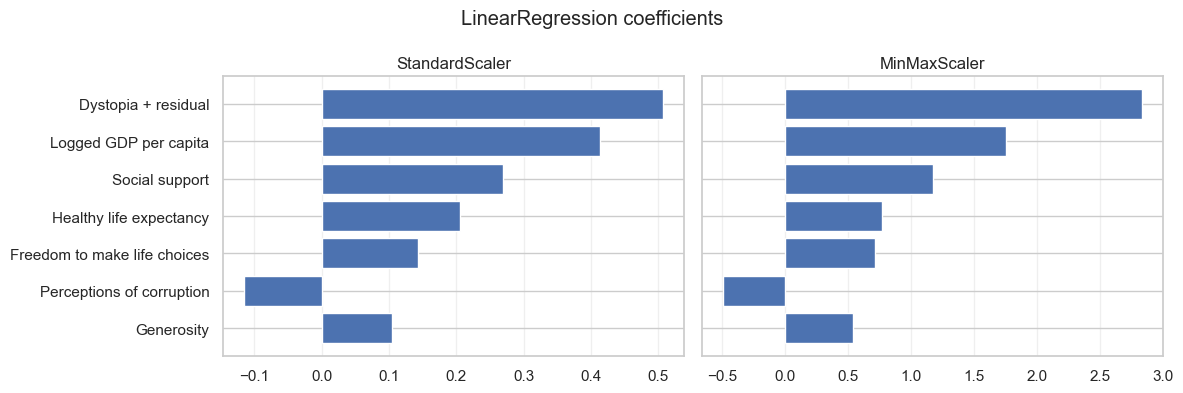

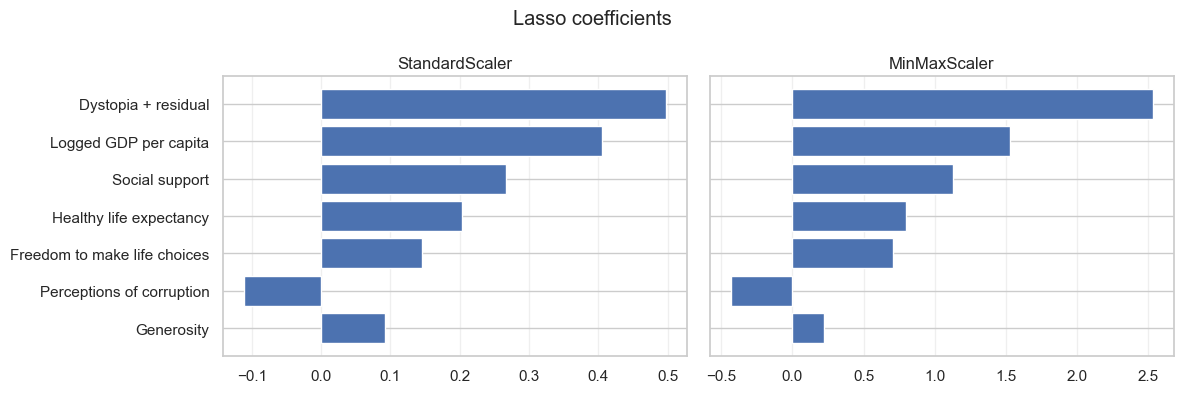

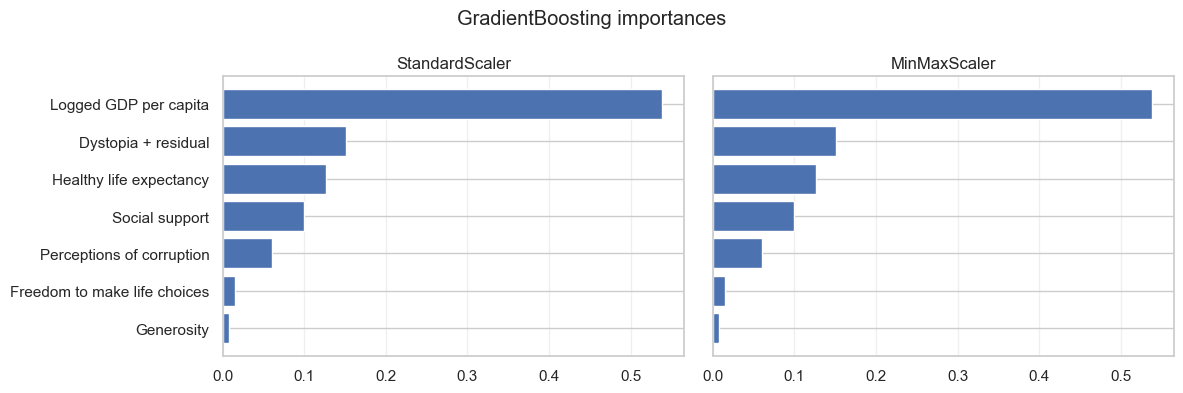

In [4]:
def plot_pair_importance(model_a, model_b, title, kind="coef"):
    if kind == "coef":
        values_a = model_a.coef_
        values_b = model_b.coef_
    else:
        values_a = model_a.feature_importances_
        values_b = model_b.feature_importances_

    order = np.argsort(np.abs(values_a))[::-1]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, values, label in zip(axes, [values_a, values_b], ["StandardScaler", "MinMaxScaler"]):
        ax.barh(np.array(feature_names)[order][::-1], values[order][::-1])
        ax.set_title(label)
        ax.grid(axis="x", alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()

plot_pair_importance(results["lr_standard"][0], results["lr_minmax"][0], "LinearRegression coefficients")
plot_pair_importance(results["lasso_standard"][0], results["lasso_minmax"][0], "Lasso coefficients")
plot_pair_importance(results["gbr_standard"][0], results["gbr_minmax"][0], "GradientBoosting importances", kind="importance")


**Вывод.** Для регрессий численные коэффициенты меняются вместе со scaler, поэтому сравнивать их можно только внутри одного масштаба. У бустинга важности почти совпадают, потому что деревья выбирают порядок и пороги, а не абсолютный масштаб.


## Задание 3. Переход между масштабами LinearRegression

Пересчитаем коэффициенты модели, обученной на MinMaxScaler, в координаты StandardScaler.


In [5]:
lr_minmax = results["lr_minmax"][0]
lr_standard = results["lr_standard"][0]

mm_min = sc_minmax.data_min_
mm_range = sc_minmax.data_range_
std_mean = sc_standard.mean_
std_scale = sc_standard.scale_

coef_std = lr_minmax.coef_ * std_scale / mm_range
intercept_std = lr_minmax.intercept_ + np.sum(lr_minmax.coef_ * (std_mean - mm_min) / mm_range)

assert round(intercept_std, 4) == round(lr_standard.intercept_, 4)
assert np.all(np.round(coef_std, 4) == np.round(lr_standard.coef_, 4))

print("Converted intercept:", round(intercept_std, 4))
pd.DataFrame({"feature": feature_names, "converted_coef": coef_std, "standard_coef": lr_standard.coef_})


Converted intercept: 5.4848


,feature,converted_coef,standard_coef
0,Logged GDP per capita,0.413565,0.413565
1,Social support,0.269675,0.269675
2,Healthy life expectancy,0.205068,0.205068
3,Freedom to make life choices,0.143662,0.143662
4,Generosity,0.104034,0.104034
5,Perceptions of corruption,-0.115983,-0.115983
6,Dystopia + residual,0.506863,0.506863


## Задание 4. ICE вне обучающего диапазона

Берём исходный диапазон `Logged GDP per capita` от `max` до `3 * max`, масштабируем через уже обученный scaler и смотрим, как модели экстраполируют.


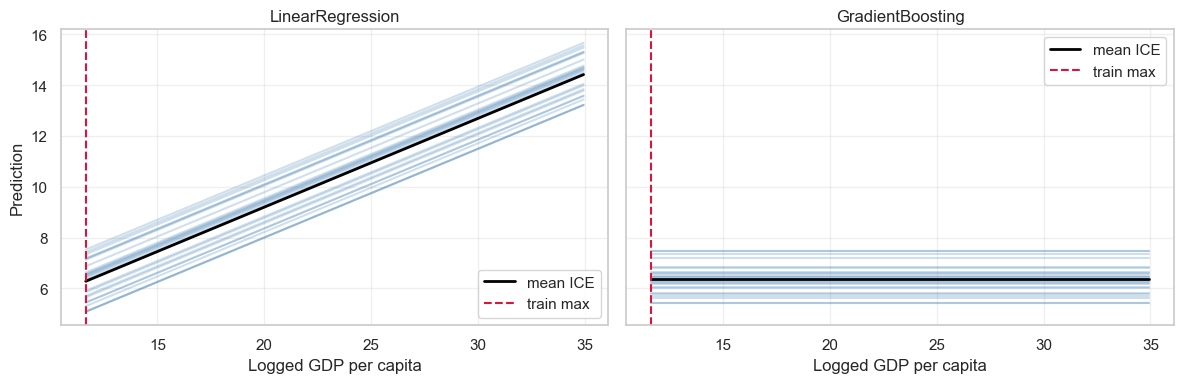

In [6]:
lr_std = results["lr_standard"][0]
gbr_std = results["gbr_standard"][0]

raw_min = X_train[feature_name].min()
raw_max = X_train[feature_name].max()
grid_raw = np.linspace(raw_max, 3 * raw_max, 20)
objects_raw = X_test.iloc[:25].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, model, title in zip(axes, [lr_std, gbr_std], ["LinearRegression", "GradientBoosting"]):
    ice = []
    for value in grid_raw:
        X_tmp = objects_raw.copy()
        X_tmp[feature_name] = value
        preds = model.predict(sc_standard.transform(X_tmp))
        ice.append(preds)
    ice = np.array(ice)
    ax.plot(grid_raw, ice, color="steelblue", alpha=0.25)
    ax.plot(grid_raw, ice.mean(axis=1), color="black", linewidth=2, label="mean ICE")
    ax.axvline(raw_max, color="crimson", linestyle="--", label="train max")
    ax.set_title(title)
    ax.set_xlabel(feature_name)
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("Prediction")
plt.tight_layout()


**Вывод.** Линейная регрессия продолжает линейный тренд далеко за пределами наблюдений. Бустинг экстраполирует кусочно-постоянно: за последним виденным порогом деревья почти не умеют создавать новый тренд.


## Задание 5. PDP


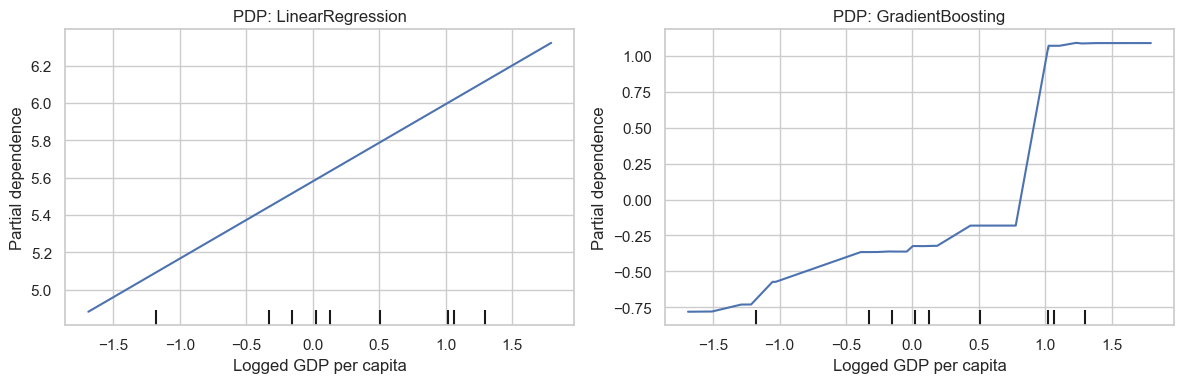

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
PartialDependenceDisplay.from_estimator(lr_std, X_test_standard, [feature_idx], feature_names=feature_names, ax=axes[0])
axes[0].set_title("PDP: LinearRegression")
PartialDependenceDisplay.from_estimator(gbr_std, X_test_standard, [feature_idx], feature_names=feature_names, ax=axes[1])
axes[1].set_title("PDP: GradientBoosting")
plt.tight_layout()


**Вывод.** PDP — это средняя ICE-кривая. Для линейной модели она почти прямая, для бустинга видны ступеньки и локальные нелинейности.


## Задание 6. ALE


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


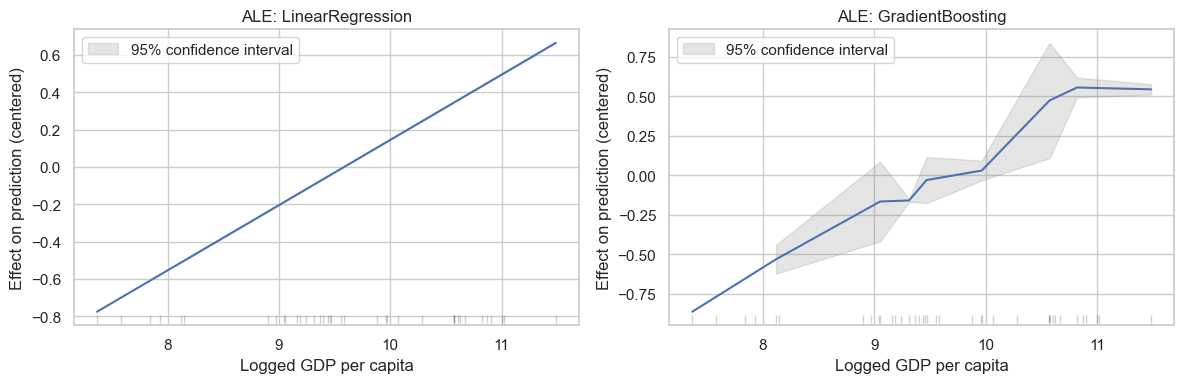

In [8]:
from PyALE import ale

class ScaledRegressor:
    def __init__(self, model, scaler, columns):
        self.model = model
        self.scaler = scaler
        self.columns = list(columns)

    def predict(self, X):
        X_df = pd.DataFrame(X, columns=self.columns)
        return self.model.predict(self.scaler.transform(X_df))

X_test_raw = X_test.reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ale(X=X_test_raw, model=ScaledRegressor(lr_std, sc_standard, feature_names), feature=[feature_name], grid_size=8, include_CI=True, fig=fig, ax=axes[0])
axes[0].set_title("ALE: LinearRegression")
ale(X=X_test_raw, model=ScaledRegressor(gbr_std, sc_standard, feature_names), feature=[feature_name], grid_size=8, include_CI=True, fig=fig, ax=axes[1])
axes[1].set_title("ALE: GradientBoosting")
plt.tight_layout()


**Вывод.** ALE оценивает локальные изменения внутри областей, где есть данные, поэтому он устойчивее к нереалистичным комбинациям признаков, чем PDP. Доверительные интервалы у бустинга шире и менее гладкие: локальный эффект у деревьев меняется скачками и сильнее зависит от конкретных объектов.


## Задание 7. Permutation importance


n_repeats,5,15,40
model,,,
GradientBoosting,0.034250,0.040652,0.038702
LinearRegression,0.029745,0.031391,0.029792


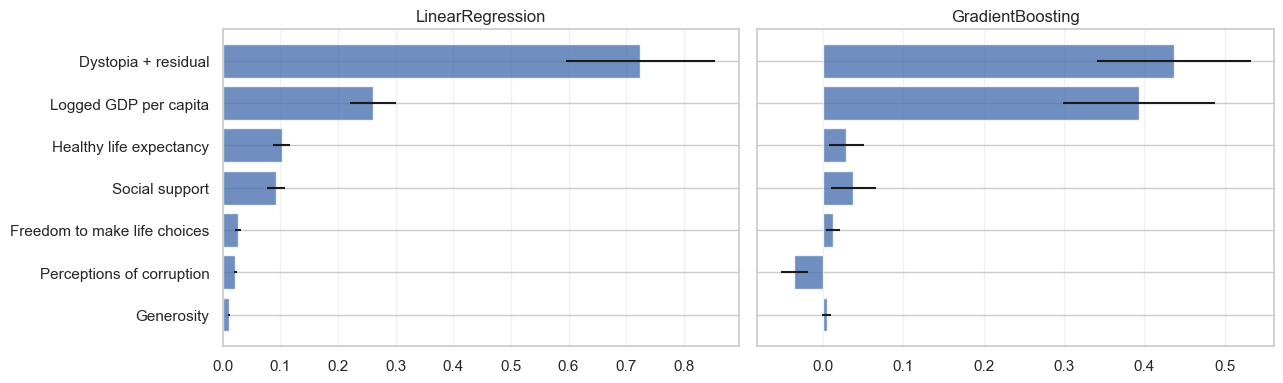

In [9]:
perm_rows = []
for n_repeats in [5, 15, 40]:
    for model_name, model in [("LinearRegression", lr_std), ("GradientBoosting", gbr_std)]:
        perm = permutation_importance(
            model,
            X_test_standard,
            y_test,
            scoring="neg_mean_squared_error",
            n_repeats=n_repeats,
            random_state=RANDOM_STATE,
        )
        for feature, mean, std in zip(feature_names, perm.importances_mean, perm.importances_std):
            perm_rows.append({"model": model_name, "n_repeats": n_repeats, "feature": feature, "importance": mean, "std": std})

perm_df = pd.DataFrame(perm_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, model_name in zip(axes, ["LinearRegression", "GradientBoosting"]):
    plot_df = perm_df[(perm_df.model == model_name) & (perm_df.n_repeats == 40)].sort_values("importance")
    ax.barh(plot_df["feature"], plot_df["importance"], xerr=plot_df["std"], alpha=0.8)
    ax.set_title(model_name)
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

perm_df.groupby(["model", "n_repeats"])["std"].mean().unstack()


**Вывод.** При росте числа перестановок средние важности стабилизируются, а оценка стандартного отклонения становится надёжнее. Самые важные признаки совпадают с интуицией WHR: GDP, social support, health и residual.


## Задание 8. Occlusion importance


,feature,beta,delta_mse
5,Perceptions of corruption,0.2,0.003978
4,Generosity,0.2,0.000348
3,Freedom to make life choices,0.2,-0.000002
2,Healthy life expectancy,0.2,-0.001095
1,Social support,0.2,-0.007953
6,Dystopia + residual,0.2,-0.014980
0,Logged GDP per capita,0.2,-0.023924
7,Logged GDP per capita,0.5,0.071749
13,Dystopia + residual,0.5,0.049700
11,Generosity,0.5,0.003106


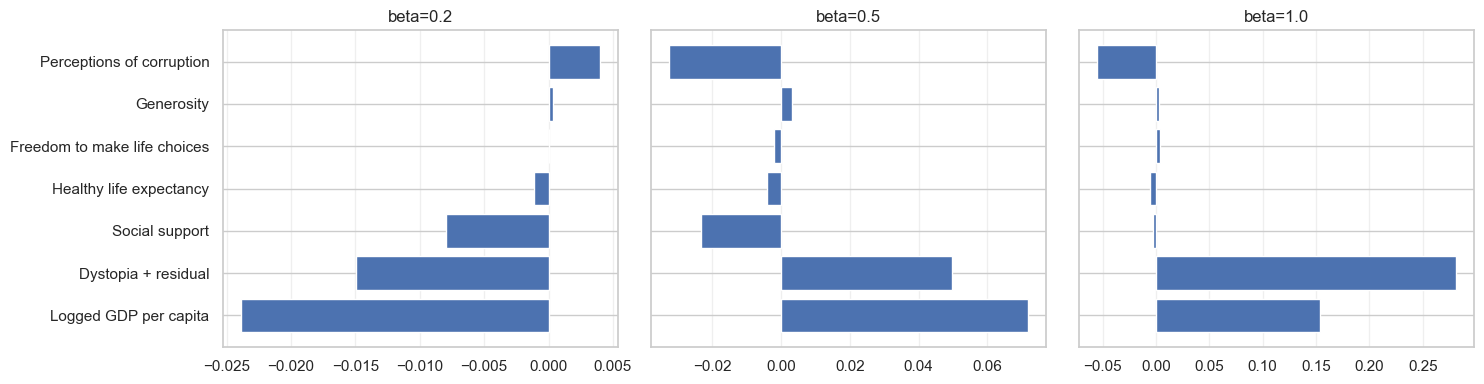

In [10]:
def occlusion_importance(model, X_raw, y_true, scaler, betas=(0.2, 0.5, 1.0)):
    X_raw = X_raw.copy()
    baseline_pred = model.predict(scaler.transform(X_raw))
    baseline_mse = mean_squared_error(y_true, baseline_pred)
    medians = X_train.median()
    rows = []

    for beta in betas:
        for feature in X_raw.columns:
            X_shifted = X_raw.copy()
            X_shifted[feature] = (1 - beta) * X_shifted[feature] + beta * medians[feature]
            shifted_pred = model.predict(scaler.transform(X_shifted))
            rows.append({
                "feature": feature,
                "beta": beta,
                "delta_mse": mean_squared_error(y_true, shifted_pred) - baseline_mse,
            })
    return pd.DataFrame(rows)

occ_df = occlusion_importance(gbr_std, X_test, y_test, sc_standard)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, beta in zip(axes, [0.2, 0.5, 1.0]):
    plot_df = occ_df[occ_df.beta == beta].sort_values("delta_mse")
    ax.barh(plot_df["feature"], plot_df["delta_mse"])
    ax.set_title(f"beta={beta}")
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

occ_df.sort_values(["beta", "delta_mse"], ascending=[True, False]).head(10)


**Вывод.** При увеличении `beta` признак сильнее сдвигается к медиане, поэтому потеря качества обычно растёт. Ранжирование похоже на permutation importance, но occlusion менее разрушителен: он не создаёт случайную перестановку, а плавно гасит индивидуальность признака.


## Задание 9. SHAP: глобальные графики


shap:WARNING: Background dataset has 111 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=111 when initializing the masker.


shap:WARNING: Background dataset has 111 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=111 when initializing the masker.


<Figure size 640x480 with 0 Axes>

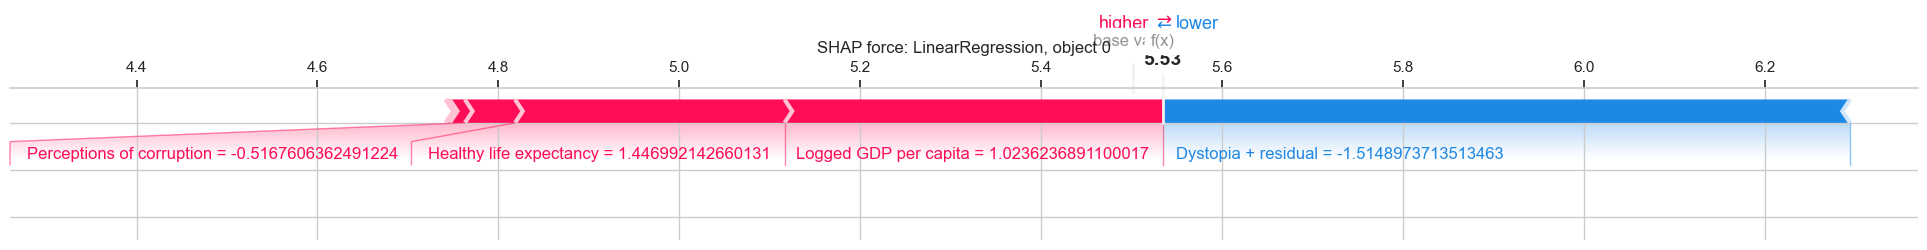

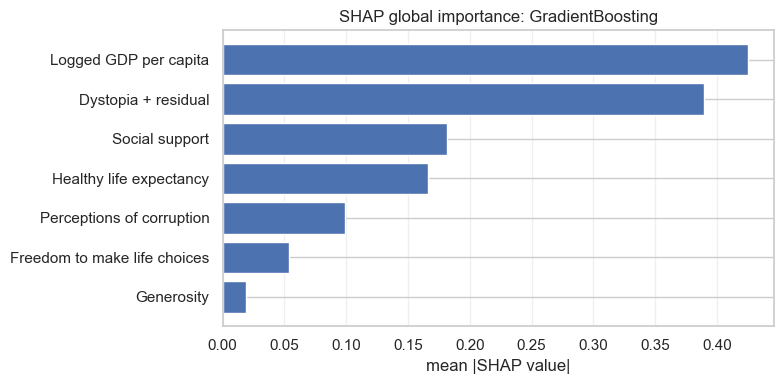

In [11]:
import shap

shap.initjs()
X_shap = X_test_standard[:40]

lr_explainer = shap.LinearExplainer(lr_std, masker=shap.maskers.Independent(data=X_train_standard))
lr_shap = lr_explainer(X_shap)

gbr_explainer = shap.Explainer(gbr_std, X_train_standard)
gbr_shap = gbr_explainer(X_shap, check_additivity=False)

plt.figure()
shap.plots.force(lr_shap.base_values[0], lr_shap.values[0], X_shap[0], feature_names=feature_names, matplotlib=True, show=False)
plt.title("SHAP force: LinearRegression, object 0")
plt.tight_layout()

global_shap = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(gbr_shap.values).mean(axis=0),
}).sort_values("mean_abs_shap")

plt.figure(figsize=(8, 4))
plt.barh(global_shap["feature"], global_shap["mean_abs_shap"])
plt.title("SHAP global importance: GradientBoosting")
plt.xlabel("mean |SHAP value|")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

**Вывод.** Для линейной модели SHAP фактически повторяет стандартизированные коэффициенты с учётом значения признака у объекта. Для бустинга глобально сильнее всего выделяются `Dystopia + residual`, GDP, social support и health-related признаки.


## Задание 10. SHAP: локальный объект 7


In [12]:
object_idx = 7

plt.figure()
shap.plots.waterfall(lr_shap[object_idx], max_display=len(feature_names), show=False)
plt.title("LinearRegression SHAP, object 7")
plt.tight_layout()

plt.figure()
shap.plots.waterfall(gbr_shap[object_idx], max_display=len(feature_names), show=False)
plt.title("GradientBoosting SHAP, object 7")
plt.tight_layout()


**Вывод.** У объекта 7 итоговый прогноз складывается из базового уровня и вкладов отдельных факторов. Линейная модель объясняет вклад монотонно через коэффициенты, а бустинг может давать более локальные и нелинейные вклады.


## Задание 11. LIME


In [13]:
from lime.lime_tabular import LimeTabularExplainer

kernel_width = np.sqrt(len(feature_names)) * 0.75
lime_explainer = LimeTabularExplainer(
    X_train_standard,
    feature_names=feature_names,
    mode="regression",
    kernel_width=kernel_width,
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

lime_lr = lime_explainer.explain_instance(X_test_standard[7], lr_std.predict, num_features=len(feature_names))
lime_gbr = lime_explainer.explain_instance(X_test_standard[7], gbr_std.predict, num_features=len(feature_names))

fig = lime_lr.as_pyplot_figure()
fig.suptitle("LIME: LinearRegression, object 7")
plt.tight_layout()

fig = lime_gbr.as_pyplot_figure()
fig.suptitle("LIME: GradientBoosting, object 7")
plt.tight_layout()


**Вывод.** Для линейной модели LIME близок к SHAP: локальная линейная аппроксимация совпадает с глобальной линейностью. Для бустинга LIME объясняет только окрестность объекта, поэтому ранжирование может отличаться от SHAP, который усредняет маржинальные вклады по коалициям.


## Задание 12. LIME своими руками


In [14]:
def manual_lime_coefficients(model, x0, X_background, n=1000, kernel_width=None, kernel="exponential", seed=42):
    rng = np.random.default_rng(seed)
    X_background = np.asarray(X_background)
    x0 = np.asarray(x0)
    scale = X_background.std(axis=0) + 1e-6
    samples = x0 + rng.normal(0, scale, size=(n, X_background.shape[1]))
    samples[0] = x0

    distances = np.linalg.norm((samples - x0) / scale, axis=1)
    if kernel_width is None:
        kernel_width = np.sqrt(X_background.shape[1]) * 0.75
    if kernel == "exponential":
        weights = np.exp(-(distances ** 2) / (kernel_width ** 2))
    elif kernel == "inverse":
        weights = 1 / (1 + distances)
    else:
        raise ValueError("Unknown kernel")

    y_local = model.predict(samples)
    surrogate = LinearRegression()
    surrogate.fit(samples, y_local, sample_weight=weights)
    return surrogate.coef_, surrogate.intercept_

manual_rows = []
for n in [200, 1000, 3000]:
    for kernel in ["exponential", "inverse"]:
        coef, intercept = manual_lime_coefficients(gbr_std, X_test_standard[7], X_train_standard, n=n, kernel=kernel, seed=RANDOM_STATE)
        for feature, value in zip(feature_names, coef):
            manual_rows.append({"n": n, "kernel": kernel, "feature": feature, "coef": value, "abs_coef": abs(value)})

manual_lime_df = pd.DataFrame(manual_rows)
summary = manual_lime_df.pivot_table(index="feature", columns=["kernel", "n"], values="coef")
summary


kernel                       exponential                       inverse  \
n                                   200       1000      3000      200    
feature                                                                  
Dystopia + residual             0.328943  0.308887  0.320629  0.291871   
Freedom to make life choices    0.029972  0.038411  0.042095  0.003677   
Generosity                      0.031950  0.063898  0.058040  0.055911   
Healthy life expectancy         0.166622  0.195097  0.207159  0.157503   
Logged GDP per capita           0.183893  0.184891  0.177284  0.157550   
Perceptions of corruption      -0.179812 -0.156487 -0.140991 -0.152759   
Social support                  0.243925  0.290399  0.287086  0.204801   

kernel                                            
n                                 1000      3000  
feature                                           
Dystopia + residual           0.292738  0.304910  
Freedom to make life choices  0.026870  0.034774  
Generosity                    0.050597  0.056415  
Healthy life expectancy       0.179448  0.192269  
Logged GDP per capita         0.183787  0.182600  
Perceptions of corruption    -0.128524 -0.114147  
Social support                0.253657  0.256792

In [15]:
plot_df = manual_lime_df[(manual_lime_df.n == 3000) & (manual_lime_df.kernel == "exponential")].sort_values("abs_coef")
plt.figure(figsize=(8, 4))
plt.barh(plot_df["feature"], plot_df["coef"])
plt.title("Manual LIME coefficients for GradientBoosting")
plt.xlabel("local coefficient")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()


**Вывод.** При малом числе сэмплов коэффициенты заметно шумят. При `n=1000-3000` ранжирование становится стабильнее. Выбор ядра влияет на ширину окрестности: exponential сильнее концентрируется вокруг объекта, inverse даёт больший вес дальним точкам и делает объяснение менее локальным.


## Источники

Использованы документация `sklearn`, `shap`, `lime`, `PyALE` и датасет World Happiness Report из ссылки в условии.
